In [1]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt
from gpytorch.means import ConstantMean, ZeroMean
from gpytorch.kernels import CosineKernel, RQKernel, ScaleKernel, PeriodicKernel, RBFKernel
from gpytorch.models import ExactGP

In [2]:
class ExactGPModel(ExactGP):
    def __init__(self, train_x, train_y, likelihood, mean_module, kernel,
                 constant_bounds=None, length_scale_bounds=None, noise_level_bounds=None):
        """
        Gaussian Process model that uses the composite kernel
            ScaleKernel( CosineKernel() * RQKernel() ).
        If bounds are provided, the outputscale and RQ lengthscale are constrained.
        """
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.noise_level_bounds = noise_level_bounds
        self.mean_module = mean_module
        self.covar_module = kernel
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [12]:
time_1 = np.load("time_domain_sampled1.npy")
state_1 = np.load("state_variable_sampled1.npy")
train_x = np.load("train_x.npy")
train_y = np.load("train_y.npy")
train_x.shape

(250, 1)

(250,) (250,)


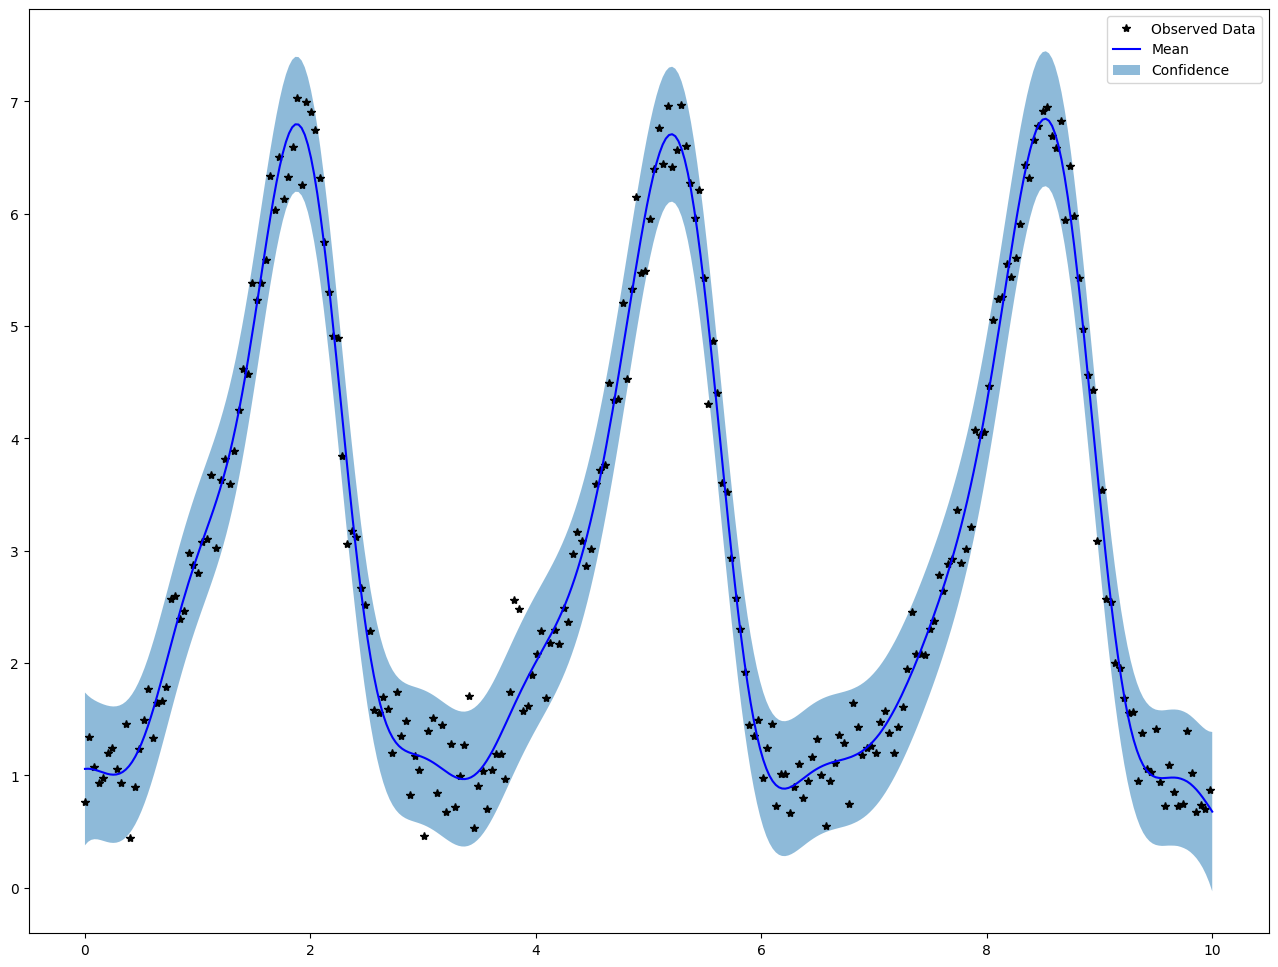

In [13]:
# Fit 1
import gpytorch.constraints


# time_1 = np.load("time_domain_sampled1.npy")
# state_1 = np.load("state_variable_sampled1.npy")
time_1 = np.load("train_x.npy").squeeze(1)
state_1 =  np.load("train_y.npy")
print(time_1.shape, state_1.shape)
# plt.plot(time_1,state_1)
torch_time_1 = torch.from_numpy(time_1).float()
torch_state_1 = torch.from_numpy(state_1).float()
likelihood = gpytorch.likelihoods.GaussianLikelihood()
# kernel = ScaleKernel(PeriodicKernel()*RQKernel())
kernel = ScaleKernel(CosineKernel(
    # period_length_constraint=gpytorch.constraints.Interval(1,2)
)*RBFKernel())
mean = ZeroMean()
model = ExactGPModel(torch_time_1, torch_state_1, likelihood=likelihood, mean_module=mean, kernel=kernel)

# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(500):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(torch_time_1)
    # Calc loss and backprop gradients
    loss = -mll(output, torch_state_1)
    loss.backward()
    optimizer.step()

model.eval()
# print(model.covar_module.base_kernel.period_length)
t = torch.linspace(0,10,360)
observed_pred = likelihood(model(t))

with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(16, 12))

    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()
    # Plot training data as black stars
    ax.plot(torch_time_1.numpy(), torch_state_1.numpy(), 'k*')
    # Plot predictive means as blue line
    ax.plot(t.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(t.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    # ax.set_ylim([0, 8])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])

In [14]:
# '''
# Standard implementation for RBF
# '''
# rbf_yy = model.covar_module(torch_time_1, torch_time_1)  # (m, m)
# rbf_zy = model.covar_module(t, torch_time_1)             # (m', m)
# rbf_zz = model.covar_module(t, t)                         # (m', m')
# # Compute pairwise differences.
# tprime_minus_tprime = t.unsqueeze(1) - t.unsqueeze(0)
# tprime_minus_t = t.unsqueeze(1) - torch_time_1.unsqueeze(0)
# ell2 = model.covar_module.lengthscale ** 2

# # Add noise to the diagonal.
# noise = model.likelihood.noise.item()
# K_yy = rbf_yy + torch.diag(torch.full((rbf_yy.size(0),), noise, 
#                                         dtype=rbf_yy.dtype, 
#                                         device=rbf_yy.device))
# # First derivative
# K_zy = -tprime_minus_t * rbf_zy / ell2
# # Second derivative
# K_zz = (1 - (tprime_minus_tprime ** 2 / ell2)) * rbf_zz / ell2


# eta = 1e-4
# L = torch.linalg.cholesky(K_yy.to_dense())
# y_unsq = torch_state_1.unsqueeze(-1)  # shape (m, 1)
# K_yy_inv_y = torch.cholesky_solve(y_unsq, L)
# state_estimate = (rbf_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float32)
# ddt_estimate = (K_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float64)
# K_zy_inv = torch.cholesky_solve(K_zy.to_dense().T, L)
# ddt_covariance = K_zz - K_zy @ K_zy_inv
# ddt_covariance = ddt_covariance
# C = ddt_covariance
# C_reg = C + eta * torch.eye(C.size(0), device=C.device, dtype=C.dtype)
# evals, evecs = torch.linalg.eigh(C_reg)
# if torch.any(evals <= 0):
#     print(evals.min())
#     raise ValueError(f"inverse covariance not positive definite, increase eta...previous value {eta}")
# sqrtW = (evecs @ torch.diag(1.0 / torch.sqrt(evals)) @ evecs.T).detach().numpy().astype(np.float64)

In [15]:
# '''
# Implementation for Cosine
# '''
# # First derivative
# k_yy = model.covar_module(torch_time_1, torch_time_1)  # (m, m)
# k_zy = model.covar_module(t, torch_time_1)             # (m', m)
# k_zz = model.covar_module(t, t)                         # (m', m')
# # Compute pairwise differences.
# tprime_minus_tprime = t.unsqueeze(1) - t.unsqueeze(0)
# tprime_minus_t = t.unsqueeze(1) - torch_time_1.unsqueeze(0)

# p = 3
# a = p/torch.pi
# K_zy = -a*torch.sin(a*torch.norm(tprime_minus_t))*tprime_minus_t/torch.norm(tprime_minus_t) 
# term1 = a**2*torch.cos(a*torch.norm(tprime_minus_tprime))*tprime_minus_tprime**2/torch.norm(tprime_minus_tprime)**2
# term2 = a*torch.sin(a*torch.norm(tprime_minus_tprime))*torch.eye(n=tprime_minus_tprime.shape[0], m=tprime_minus_tprime.shape[1])/torch.norm(tprime_minus_tprime)
# term3 = -a*torch.sin(a*torch.norm(tprime_minus_tprime))*tprime_minus_tprime**2/torch.norm(tprime_minus_tprime)**3
# K_zz = term1 + term2 + term3

# noise = model.likelihood.noise.item()
# K_yy = k_yy + torch.diag(torch.full((k_yy.size(0),), noise, 
#                                         dtype=k_yy.dtype, 
#                                         device=k_yy.device))
# K_zy.shape, K_zz.shape, K_yy.shape

# eta = 1e-1
# L = torch.linalg.cholesky(K_yy.to_dense())
# y_unsq = torch_state_1.unsqueeze(-1)  # shape (m, 1)
# K_yy_inv_y = torch.cholesky_solve(y_unsq, L)
# state_estimate = (k_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float32)
# ddt_estimate = (K_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float64)
# K_zy_inv = torch.cholesky_solve(K_zy.to_dense().T, L)
# ddt_covariance = K_zz - K_zy @ K_zy_inv
# ddt_covariance = ddt_covariance
# C = ddt_covariance
# C_reg = C + eta * torch.eye(C.size(0), device=C.device, dtype=C.dtype)
# evals, evecs = torch.linalg.eigh(C_reg)
# if torch.any(evals <= 0):
#     print(evals.min())
#     raise ValueError(f"inverse covariance not positive definite, increase eta...previous value {eta}")
# sqrtW = (evecs @ torch.diag(1.0 / torch.sqrt(evals)) @ evecs.T).detach().numpy().astype(np.float64)

In [16]:
'''
Implementation for Cosine * RBF
'''
"""
Implementation for Cosine * RBF kernels
"""
print(torch_time_1.shape, t.shape)

# Compute kernel matrices (assumes model.covar_module is callable with two inputs)
k_yy = model.covar_module(torch_time_1, torch_time_1)  # shape: (m, m)
k_zy = model.covar_module(t, torch_time_1)             # shape: (m', m)
k_zz = model.covar_module(t, t)                         # shape: (m', m')

# Compute pairwise differences.
tprime_minus_tprime = t.unsqueeze(1) - t.unsqueeze(0)
tprime_minus_t      = t.unsqueeze(1) - torch_time_1.unsqueeze(0)

# Evaluate cosine and RBF kernel components and convert to dense tensors.
cos_zy = model.covar_module.base_kernel.kernels[0](t, torch_time_1).to_dense()
cos_zz = model.covar_module.base_kernel.kernels[0](t, t).to_dense()
rbf_zy = model.covar_module.base_kernel.kernels[1](t, torch_time_1).to_dense()
rbf_zz = model.covar_module.base_kernel.kernels[1](t, t).to_dense()

# Square of the lengthscale for the RBF kernel.
ell2 = model.covar_module.base_kernel.kernels[1].lengthscale ** 2

# Constants.
p = 3
a = p / torch.pi

# -------------------------
# First Derivative
# -------------------------
# k'_rbf * k_cos + k_rbf * k'_cos
norm_tprime_minus_t = torch.norm(tprime_minus_t)
k_prime_cos = -a * torch.sin(a * norm_tprime_minus_t) * tprime_minus_t / norm_tprime_minus_t
k_prime_rbf = -tprime_minus_t * rbf_zy / ell2
K_zy = k_prime_rbf * cos_zy + rbf_zy * k_prime_cos

# -------------------------
# Second Derivatives
# -------------------------
norm_tprime_minus_tprime = torch.norm(tprime_minus_tprime)
# Terms for the cosine second derivative.
term1 = a**2 * torch.cos(a * norm_tprime_minus_tprime) * (tprime_minus_tprime**2) / (norm_tprime_minus_tprime**2)
term2 = a * torch.sin(a * norm_tprime_minus_tprime) * torch.eye(tprime_minus_tprime.shape[0],
                                                                 tprime_minus_tprime.shape[1]) / norm_tprime_minus_tprime
term3 = -a * torch.sin(a * norm_tprime_minus_tprime) * (tprime_minus_tprime**2) / (norm_tprime_minus_tprime**3)
dx1dx2_k_cos = term1 + term2 + term3

# Terms for the RBF second derivative.
dx1dx2_k_rbf = (1 - (tprime_minus_tprime**2 / ell2)) * rbf_zz / ell2
dx2_k_rbf    = tprime_minus_tprime * rbf_zz / ell2
dx2_k_cos    = a * torch.sin(a * norm_tprime_minus_tprime) * tprime_minus_tprime / norm_tprime_minus_tprime

# Combined second derivative (note the grouping of terms).
K_zz = (
    dx1dx2_k_rbf * cos_zz
    + dx2_k_rbf * (-a * torch.sin(a * norm_tprime_minus_tprime) * tprime_minus_tprime / norm_tprime_minus_tprime)
    - (tprime_minus_tprime * rbf_zz / ell2) * (a * torch.sin(a * norm_tprime_minus_tprime) * tprime_minus_tprime / norm_tprime_minus_tprime)
    + rbf_zz * dx1dx2_k_cos
)


noise = model.likelihood.noise.item()
K_yy = k_yy + torch.diag(torch.full((k_yy.size(0),), noise, 
                                        dtype=k_yy.dtype, 
                                        device=k_yy.device))

eta = 1e-2
L = torch.linalg.cholesky(K_yy.to_dense())
y_unsq = torch_state_1.unsqueeze(-1)  # shape (m, 1)
K_yy_inv_y = torch.cholesky_solve(y_unsq, L)
state_estimate = (k_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float32)
ddt_estimate = (K_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float64)
K_zy_inv = torch.cholesky_solve(K_zy.to_dense().T, L)
ddt_covariance = K_zz - K_zy @ K_zy_inv
ddt_covariance = ddt_covariance
C = ddt_covariance
C_reg = C + eta * torch.eye(C.size(0), device=C.device, dtype=C.dtype)
evals, evecs = torch.linalg.eigh(C_reg)
print(evals.min())
if torch.any(evals <= 0):
    print(evals.min())
    raise ValueError(f"inverse covariance not positive definite, increase eta...previous value {eta}")
sqrtW = (evecs @ torch.diag(1.0 / torch.sqrt(evals)) @ evecs.T).detach().numpy().astype(np.float64)

torch.Size([250]) torch.Size([360])
tensor(0.0099, grad_fn=<MinBackward1>)


In [ ]:
"""
Use autograd?
"""
t = torch.linspace(0,10, 150, requires_grad=True)
yy = model.covar_module(t,t).to_dense()
yy = torch.autograd.grad(yy, t, create_graph=True)

RuntimeError: grad can be implicitly created only for scalar outputs

In [ ]:
'''
Possible Implementation for Scale(RQ*Periodic)
'''
import torch
import math

def periodic_factor_1d(t_diff, lmbda, period):
    """
    Returns the 1D periodic kernel factor:
       k_per = exp( - 2/lambda * sin^2( (pi/period) * diff ) ).
    """
    a = math.pi / period
    sin_arg = torch.sin(a * t_diff)
    k_per = torch.exp(-2.0 / lmbda * sin_arg**2)
    return k_per

def periodic_factor_1d_first_deriv(t_diff, lmbda, period):
    """
    Derivative wrt t of the periodic factor k_per(t, t'):
      d/dt [k_per] = (dk_per/d(diff)) * (d(diff)/dt).
    Since diff = t - t', derivative wrt t is the same as derivative wrt diff.
    
    We return dk_per/d(diff).
    """
    a = math.pi / period
    sin_arg = torch.sin(a * t_diff)
    k_per = periodic_factor_1d(t_diff, lmbda, period)
    # exponent derivative is: -2/lambda * derivative of sin^2(a*diff)
    # derivative sin^2(x) = sin(2x). Then chain rule => * a
    # => final factor: -2/lmbda * a * sin(2 a diff)
    # So:
    dk_per_ddiff = k_per * (-2.0 * a / lmbda) * torch.sin(2.0 * a * t_diff)
    return dk_per_ddiff

def periodic_factor_1d_second_deriv(t_diff, lmbda, period):
    """
    Second derivative wrt t of the periodic factor, i.e. d^2 k_per / d(diff^2).
    We'll compute it explicitly using:
      k_per = exp(exponent),
      exponent = -2/lambda * sin^2(a*diff),
      exponent' = derivative wrt diff,
      exponent'' = second derivative wrt diff.
      
      d^2 k_per / d diff^2 = k_per * [ (exponent')^2 + exponent'' ].
    """
    a = math.pi / period
    
    # base kernel
    k_per = periodic_factor_1d(t_diff, lmbda, period)
    # exponent = -2/lmbda * sin^2(a*diff)
    # exponent' wrt diff:
    exponent_prime = -2.0/lmbda * (a * torch.sin(2.0*a*t_diff))  # a*sin(2a diff)
    # exponent'' wrt diff:
    # derivative of  [ -2.0/lmbda * a sin(2 a diff ) ]
    # => -2.0/lmbda * a * [ 2 a cos(2 a diff ) ] => -4 a^2 / lmbda cos(2 a diff)
    exponent_second = -4.0 * (a**2) / lmbda * torch.cos(2.0 * a * t_diff)
    
    # so second deriv of k_per:
    k_per_ddiff = k_per * (exponent_prime**2 + exponent_second)
    return k_per_ddiff

def rq_factor_1d(t_diff, alpha, ell):
    """
    Returns the 1D RQ factor:
       k_rq = ( 1 + diff^2 / (2 alpha ell^2) )^(-alpha).
    """
    # r = 1 + diff^2/(2 alpha ell^2)
    r = 1.0 + (t_diff**2) / (2.0 * alpha * ell**2)
    k_rq = r.pow(-alpha)
    return k_rq

def rq_factor_1d_first_deriv(t_diff, alpha, ell):
    """
    Derivative wrt t of the RQ factor (which is derivative wrt diff).
    
    If k_rq = r^-alpha,  with r = 1 + diff^2/(2 alpha ell^2),
    then dr/d(diff) = diff / (alpha ell^2),
    and dk_rq/d(diff) = - alpha r^-alpha-1 * dr/d(diff),
    which simplifies to  - r^-alpha-1 * diff / ell^2,
    or equivalently - (k_rq / r) * diff / ell^2.
    """
    t_diff = t_diff.detach() if not t_diff.requires_grad else t_diff  # up to you
    r = 1.0 + (t_diff**2) / (2.0 * alpha * ell**2)
    k_rq = r.pow(-alpha)
    # derivative wrt diff
    # => - k_rq / r * (diff / ell^2)
    dk_rq_ddiff = - (k_rq / r) * (t_diff / (ell**2))
    return dk_rq_ddiff, k_rq

def rq_factor_1d_second_deriv(t_diff, alpha, ell):
    """
    Second derivative wrt diff of the RQ factor.
    One can do it via the log-form approach or direct product rule.
    We'll do a more explicit version here:
    
    Let exponent_rq = -alpha * log(r). Then k_rq = exp(exponent_rq).
    derivative wrt diff => k_rq' = k_rq * exponent_rq'.
    second derivative => k_rq'' = k_rq * ( exponent_rq'^2 + exponent_rq'' ).
    We'll compute exponent_rq' and exponent_rq''.
    """
    # r = 1 + diff^2/(2 alpha ell^2)
    r = 1.0 + (t_diff**2) / (2.0 * alpha * ell**2)
    k_rq = r.pow(-alpha)
    
    # exponent_rq = -alpha * log(r)
    # exponent_rq' wrt diff => -alpha * (1/r)* dr/d(diff)
    # dr/d(diff) = diff/(alpha ell^2)
    # => exponent_rq' = - diff / (r ell^2)
    exponent_rq_prime = - t_diff / (r * ell**2)
    
    # exponent_rq'' = derivative wrt diff of [- diff/(r ell^2)]
    # = -1/ell^2 * d/d(diff)[ diff / r ]
    # product rule => d/d(diff)[ diff / r ] = [r - diff*r'] / r^2
    # but r' = diff/(alpha ell^2).
    # => r - diff*r' = r - diff*(diff/(alpha ell^2)) = r - diff^2/(alpha ell^2).
    # r = 1 + diff^2/(2 alpha ell^2). So r - diff^2/(alpha ell^2) = 1 + diff^2/(2 alpha ell^2) - diff^2/(alpha ell^2)
    # = 1 - diff^2/(2 alpha ell^2).
    # => so exponent_rq'' = -1/ell^2 * [ (1 - diff^2/(2 alpha ell^2)) / r^2 ]
    exponent_rq_second = -1.0/(ell**2) * (
        (1.0 - (t_diff**2)/(2.0 * alpha * ell**2)) / (r**2)
    )
    
    # Then k_rq'' = derivative wrt diff of (k_rq') = k_rq * (exponent_rq'^2 + exponent_rq'')
    # Because k_rq' = k_rq * exponent_rq'.
    # => second derivative:
    k_rq_ddiff = k_rq * (exponent_rq_prime**2 + exponent_rq_second)
    return k_rq_ddiff, k_rq

# ---------------------------------------------------------------------------
#        Putting it all together for the product: k = sigma^2 * (per)(rq)
# ---------------------------------------------------------------------------

def periodic_rq_kernel_1d(t1, t2, sigma, lmbda, period, alpha, ell):
    """
    The base kernel function (no derivatives), shape = [len(t1), len(t2)].
    """
    diff = t1.unsqueeze(1) - t2.unsqueeze(0)
    k_per = periodic_factor_1d(diff, lmbda, period)
    k_rq  = rq_factor_1d(diff, alpha, ell)
    return sigma**2 * k_per * k_rq

def periodic_rq_kernel_1d_first_deriv(t1, t2, sigma, lmbda, period, alpha, ell):
    """
    First partial derivative wrt the 't1' argument, i.e. d/d t of k(t, t').
    Output shape [len(t1), len(t2)].
    
    This matches your 'K_zy' style in the RBF snippet, except now
    we have the product of Periodic and RQ factors.
    """
    diff = t1.unsqueeze(1) - t2.unsqueeze(0)
    
    # Periodic factor + derivative wrt diff
    k_per = periodic_factor_1d(diff, lmbda, period)
    dk_per_ddiff = periodic_factor_1d_first_deriv(diff, lmbda, period)
    
    # RQ factor + derivative wrt diff
    dk_rq_ddiff, k_rq = rq_factor_1d_first_deriv(diff, alpha, ell)
    
    # chain rule for the product => d/dt [ per * rq ] = per' * rq + per * rq'
    # but 'per' wrt diff is dk_per_ddiff, 'rq' wrt diff is dk_rq_ddiff
    # multiply by sigma^2
    d_k = sigma**2 * (dk_per_ddiff * k_rq + k_per * dk_rq_ddiff)
    
    return d_k

def periodic_rq_kernel_1d_second_deriv(t1, t2, sigma, lmbda, period, alpha, ell):
    """
    Second partial derivative wrt the 't1' argument, i.e. d^2/d t^2 of k(t, t').
    Output shape [len(t1), len(t2)].

    This corresponds to your 'K_zz' style in the RBF snippet.
    """
    diff = t1.unsqueeze(1) - t2.unsqueeze(0)
    
    # Periodic pieces
    k_per = periodic_factor_1d(diff, lmbda, period)
    k_per_ddiff = periodic_factor_1d_second_deriv(diff, lmbda, period)  # second deriv
    dk_per_ddiff = periodic_factor_1d_first_deriv(diff, lmbda, period)  # first deriv
    
    # RQ pieces
    k_rq_ddiff, k_rq = rq_factor_1d_second_deriv(diff, alpha, ell)      # second deriv
    dk_rq_ddiff, _   = rq_factor_1d_first_deriv(diff, alpha, ell)       # first deriv
    
    # Now combine via product rule for second derivative:
    # d^2/dt^2 [ per * rq ] =
    #    per'' * rq  +  2 (per') (rq')  +  per * rq''.
    second_deriv = sigma**2 * (
        k_per_ddiff * k_rq
        + 2.0 * dk_per_ddiff * dk_rq_ddiff
        + k_per * k_rq_ddiff
    )
    
    return second_deriv

# ---------------------------------------------------------------------------
#    Example usage: (mimicking your RBF snippet style)
# ---------------------------------------------------------------------------

def example_driver(t_est, t_train, sigma, lmbda, period, alpha, ell, noise_level):
    """
    Illustrates how you might call the above to get K_zy, K_zz, etc.
    similar to your RBF snippet.
    """
    # Convert to tensors
    t_est_tensor   = torch.tensor(t_est,   dtype=torch.float32) if not torch.is_tensor(t_est)   else t_est
    t_train_tensor = torch.tensor(t_train, dtype=torch.float32) if not torch.is_tensor(t_train) else t_train
    
    # Base kernel blocks (no derivatives):
    #   'yy' ~ k(t_train, t_train),
    #   'zy' ~ k(t_est,   t_train),
    #   'zz' ~ k(t_est,   t_est).
    k_yy = periodic_rq_kernel_1d(t_train_tensor, t_train_tensor, sigma, lmbda, period, alpha, ell)
    k_zy = periodic_rq_kernel_1d(t_est_tensor,   t_train_tensor, sigma, lmbda, period, alpha, ell)
    k_zz = periodic_rq_kernel_1d(t_est_tensor,   t_est_tensor,   sigma, lmbda, period, alpha, ell)
    
    # Add noise on the diagonal of K_yy if desired
    m = k_yy.shape[0]
    k_yy = k_yy + torch.diag(torch.full((m,), noise_level, dtype=k_yy.dtype, device=k_yy.device))
    
    # First derivative block: d/d t_est of k(t_est, t_train)
    # shape [m_est, m_train]
    K_zy = periodic_rq_kernel_1d_first_deriv(t_est_tensor, t_train_tensor, sigma, lmbda, period, alpha, ell)
    
    # Second derivative block: d^2/d t_est^2 of k(t_est, t_est)
    # shape [m_est, m_est]
    K_zz = periodic_rq_kernel_1d_second_deriv(t_est_tensor, t_est_tensor, sigma, lmbda, period, alpha, ell)
    
    # Now you can do your usual solve steps or weight computations
    # e.g. self._compute_estimates_and_weights(k_yy, K_zy, K_zz, k_zy, eta) ...
    # For demonstration, just return them:
    return k_yy, K_zy, K_zz, k_zy

period = model.covar_module.base_kernel.kernels[0].period_length
lmbda = model.covar_module.base_kernel.kernels[0].lengthscale
alpha  = model.covar_module.base_kernel.kernels[1].alpha
rq_lengthscale = model.covar_module.base_kernel.kernels[1].lengthscale  # if available
# Here, outputscale is often the kernel amplitude
sigma = model.covar_module.outputscale  
noise_level = model.likelihood.noise.item()
print(noise_level)

K_yy, K_zy, K_zz, k_zy = example_driver(t, torch_time_1, sigma, lmbda, period, alpha, rq_lengthscale, noise_level)

AttributeError: 'RBFKernel' object has no attribute 'base_kernel'

In [ ]:
eta = 1e-4
L = torch.cholesky(K_yy.to_dense())
y_unsq = torch_state_1.unsqueeze(-1)  # shape (m, 1)
K_yy_inv_y = torch.cholesky_solve(y_unsq, L)
state_estimate = (k_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float32)
ddt_estimate = (K_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float64)
K_zy_inv = torch.cholesky_solve(K_zy.T, L)
ddt_covariance = K_zz - K_zy @ K_zy_inv
ddt_covariance = ddt_covariance
C = ddt_covariance
C_reg = C + eta * torch.eye(C.size(0), device=C.device, dtype=C.dtype)
evals, evecs = torch.linalg.eigh(C_reg)
if torch.any(evals <= 0):
    print(evals.mean())
    raise ValueError(f"inverse covariance not positive definite, increase eta...previous value {eta}")
sqrtW = (evecs @ torch.diag(1.0 / torch.sqrt(evals)) @ evecs.T).detach().numpy().astype(np.float64)

tensor(-1854.5618, grad_fn=<MeanBackward0>)


ValueError: inverse covariance not positive definite, increase eta...previous value 0.0001

TypeError: Invalid shape (500,) for image data

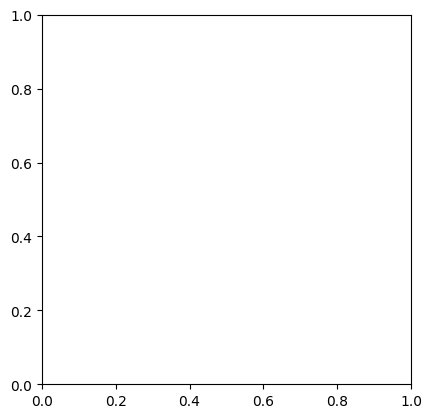

In [ ]:
# k_zz = k_zz.to_dense().detach().numpy()
# k_zy = k_zy.to_dense().detach().numpy()
# K_yy_inv_y = K_yy_inv_y.detach().numpy()
plt.imshow()
# plt.imshow(im2)

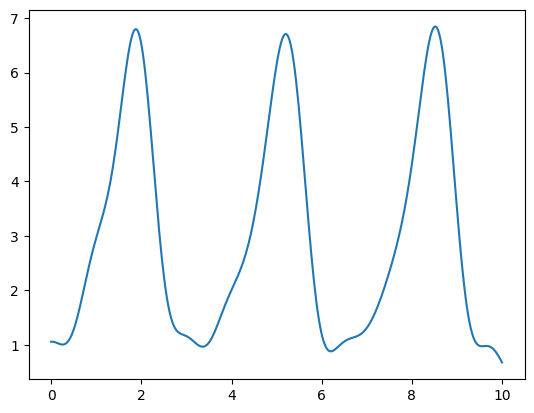

In [18]:
gp_means = np.load("lv_gp_means.npy")
x = np.linspace(0,10,360)
plt.plot(x, gp_means[0])